# 06 - ADMM Diagnostics and Parameter Sweeps

This notebook turns the ADMM reconstruction from Notebook 05 into a polished diagnostic study. The goal is not just to get a hand image. The goal is to understand **when** the image appears, **which parameters matter**, and **how to evaluate real measured data without ground truth**.

We use the Waller-Lab DiffuserCam tutorial sample data:

- measured PSF: `psf_sample.tif`
- measured raw sensor image: `rawdata_hand_sample.tif`

Portfolio goal: every figure in this notebook should tell one clear story.

## Study Questions

We will answer four practical questions:

1. **How quickly does ADMM recover recognizable structure?**
2. **How does TV strength `tau` change residual, TV value, and visual quality?**
3. **What does the predicted measurement look like compared with the real measurement?**
4. **How does ADMM compare with FISTA in runtime and residual?**

Because this is measured data, there is no exact ground truth. We therefore use residuals, objective values, TV values, predicted measurements, and visual inspection.

## Setup

In [18]:
from pathlib import Path
import sys
import json
from time import perf_counter

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'src' / 'diffusercam_sim').exists():
            return candidate
    raise RuntimeError('Could not find project root containing src/diffusercam_sim')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from diffusercam_sim import (
    PaddedLinearConvolution,
    admm_total_variation,
    find_waller_tutorial_paths,
    fista,
    preprocess_waller_tutorial_sample,
    residual_relative_l2,
)
from diffusercam_sim.admm import total_variation_anisotropic

RESULT_DIR = PROJECT_ROOT / 'results' / 'notebooks' / '06_admm_diagnostics_parameter_sweeps'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '#263238',
        'axes.labelcolor': '#263238',
        'axes.titleweight': 'bold',
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.color': '#263238',
        'ytick.color': '#263238',
        'grid.color': '#d9e0e3',
        'grid.linewidth': 0.8,
        'legend.frameon': True,
        'legend.framealpha': 0.95,
        'legend.facecolor': 'white',
        'font.size': 10,
    }
)


def save_figure(fig, path: Path):
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    return fig


def add_panel_note(ax, text: str, y: float = 0.05):
    ax.text(
        0.03,
        y,
        text,
        transform=ax.transAxes,
        fontsize=8.8,
        va='bottom',
        bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'edgecolor': '#cfd8dc', 'alpha': 0.92},
    )


def format_image_for_display(image: np.ndarray) -> np.ndarray:
    image = np.asarray(image, dtype=float)
    low, high = np.percentile(image, [1, 99.7])
    if high <= low:
        return np.zeros_like(image)
    return np.clip((image - low) / (high - low), 0, 1)


def plot_image_grid(items, path: Path, columns: int = 2, title: str | None = None):
    rows = int(np.ceil(len(items) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(4.0 * columns, 3.4 * rows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, (label, image) in zip(axes, items):
        ax.imshow(format_image_for_display(image), cmap='gray', vmin=0, vmax=1)
        ax.set_title(label)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[len(items):]:
        ax.axis('off')
    if title is not None:
        fig.suptitle(title, fontsize=15, fontweight='bold')
    return save_figure(fig, path)


def plot_admm_convergence(history, path: Path):
    iterations = np.array([record.iteration for record in history])
    objective = np.array([record.objective for record in history])
    data_fit = np.array([record.data_fit for record in history])
    residual = np.array([record.relative_residual_l2 for record in history])
    tv_value = np.array([record.tv_value for record in history])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    fig.suptitle('ADMM convergence on measured DiffuserCam hand data', fontsize=15, fontweight='bold')

    axes[0].plot(iterations, objective, marker='o', linewidth=2.4, label='objective = data fit + tau*TV')
    axes[0].plot(iterations, data_fit, marker='s', linewidth=2.0, label='data fit only')
    axes[0].set_yscale('log')
    axes[0].set_title('1. Objective terms')
    axes[0].set_xlabel('ADMM iteration')
    axes[0].set_ylabel('Energy, log scale')
    axes[0].legend(loc='best')

    axes[1].plot(iterations, residual, color='#1b7f79', marker='o', linewidth=2.4)
    axes[1].set_yscale('log')
    axes[1].set_title('2. Measurement consistency')
    axes[1].set_xlabel('ADMM iteration')
    axes[1].set_ylabel('Relative residual ||Ax-b||_2 / ||b||_2, log scale')
    add_panel_note(axes[1], 'lower means Ax better matches the sensor image')

    axes[2].plot(iterations, tv_value, color='#b24c63', marker='o', linewidth=2.4)
    axes[2].set_title('3. Image-gradient activity')
    axes[2].set_xlabel('ADMM iteration')
    axes[2].set_ylabel('Anisotropic TV value ||Dx||_1')
    add_panel_note(axes[2], 'lower means smoother / fewer sharp changes')

    for ax in axes:
        ax.grid(True, which='major')
        ax.spines[['top', 'right']].set_visible(False)

    return save_figure(fig, path)


def plot_tau_sweep(rows: list[dict[str, float]], path: Path):
    ratios = np.array([row['tau_over_mu2'] for row in rows])
    residual = np.array([row['relative_residual_l2'] for row in rows])
    tv_value = np.array([row['tv_value'] for row in rows])
    max_value = np.array([row['max_value'] for row in rows])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
    fig.suptitle('TV strength sweep after 10 ADMM iterations', fontsize=15, fontweight='bold')
    chosen_ratio = moderate_tau / admm_base_parameters['mu2']

    series = [
        (axes[0], residual, '1. Data consistency', 'Relative residual ||Ax-b||_2 / ||b||_2', '#1b7f79', 'lower is a better sensor fit'),
        (axes[1], tv_value, '2. Smoothness metric', 'TV value ||Dx||_1', '#b24c63', 'lower means stronger smoothing'),
        (axes[2], max_value, '3. Intensity scale check', 'Maximum reconstructed value', '#5d6fb3', 'large changes can indicate scaling artifacts'),
    ]
    for ax, values, panel_title, y_label, color, note in series:
        ax.plot(ratios, values, color=color, marker='o', linewidth=2.4)
        ax.axvline(chosen_ratio, color='#455a64', linestyle='--', linewidth=1.2, label='Notebook choice')
        ax.set_xscale('log')
        ax.set_title(panel_title)
        ax.set_xlabel('TV shrinkage threshold tau/mu2, log scale')
        ax.set_ylabel(y_label)
        ax.grid(True, which='both')
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(loc='best')
        add_panel_note(ax, note)

    return save_figure(fig, path)


def plot_runtime_quality(rows: list[dict[str, object]], path: Path):
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), constrained_layout=True)
    fig.suptitle('Runtime vs reconstruction diagnostics', fontsize=15, fontweight='bold')
    colors = {'FISTA': '#5d6fb3', 'ADMM-TV': '#d17a22'}

    for method in ['FISTA', 'ADMM-TV']:
        method_rows = sorted([row for row in rows if row['method'] == method], key=lambda row: row['seconds'])
        seconds = np.array([row['seconds'] for row in method_rows])
        residual = np.array([row['relative_residual_l2'] for row in method_rows])
        tv_value = np.array([row['tv_value'] for row in method_rows])
        iterations = [row['iterations'] for row in method_rows]
        axes[0].plot(seconds, residual, color=colors[method], marker='o', linewidth=2.4, label=method)
        axes[1].plot(seconds, tv_value, color=colors[method], marker='o', linewidth=2.4, label=method)
        for axis, values in [(axes[0], residual), (axes[1], tv_value)]:
            for x_value, y_value, iteration in zip(seconds, values, iterations):
                axis.annotate(str(iteration), xy=(x_value, y_value), xytext=(4, 5), textcoords='offset points', fontsize=8)

    axes[0].set_title('1. Fit per second')
    axes[0].set_xlabel('Elapsed time (seconds)')
    axes[0].set_ylabel('Relative residual ||Ax-b||_2 / ||b||_2, log scale')
    axes[0].set_yscale('log')
    add_panel_note(axes[0], 'marker labels show iteration count')
    axes[1].set_title('2. Smoothness per second')
    axes[1].set_xlabel('Elapsed time (seconds)')
    axes[1].set_ylabel('TV value ||Dx||_1')

    for ax in axes:
        ax.grid(True, which='major')
        ax.spines[['top', 'right']].set_visible(False)
        ax.legend(loc='best')

    return save_figure(fig, path)


def plot_runtime_table(rows: list[dict[str, object]], path: Path):
    columns = ['Method', 'Iter', 'Seconds', 'Rel. residual', 'TV value', 'Max value']
    table_data = [
        [
            row['method'],
            row['iterations'],
            f"{row['seconds']:.2f}",
            f"{row['relative_residual_l2']:.4f}",
            f"{row['tv_value']:.3f}",
            f"{row['max_value']:.4f}",
        ]
        for row in rows
    ]
    fig, ax = plt.subplots(figsize=(11.5, 3.2), constrained_layout=True)
    ax.axis('off')
    fig.suptitle('Runtime and quality diagnostics on Waller sample data', fontsize=14, fontweight='bold')
    table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.35)
    for (row_index, col_index), cell in table.get_celld().items():
        cell.set_edgecolor('#cfd8dc')
        if row_index == 0:
            cell.set_facecolor('#e8eef2')
            cell.set_text_props(weight='bold')
        elif row_index % 2 == 0:
            cell.set_facecolor('#f7f9fa')
    return save_figure(fig, path)

PROJECT_ROOT

WindowsPath('E:/RIT/Spring2026/ComputationalImaging/DiffuserCam2026')

## Load and Preprocess Measured Data

We use the same preprocessing pipeline as Notebooks 04 and 05:

1. Load 16-bit TIFF files.
2. Estimate background from the PSF corner patch.
3. Subtract background from PSF and measurement.
4. Downsample by repeated `2 x 2` averaging.
5. Normalize PSF and measurement to unit L2 norm.

This keeps the experiment consistent with the Waller tutorial.

In [19]:
psf_path, rawdata_path = find_waller_tutorial_paths(PROJECT_ROOT)
sample = preprocess_waller_tutorial_sample(psf_path, rawdata_path, downsample_factor=1/8)
operator = PaddedLinearConvolution(sample.psf)

data_info = {
    'psf_path': str(psf_path),
    'rawdata_path': str(rawdata_path),
    'raw_shape_rows_cols': sample.psf_raw.shape,
    'processed_shape_rows_cols': sample.psf.shape,
    'padded_shape': operator.padded_shape,
    'background': sample.background,
    'imaging_adjoint_error': operator.adjoint_inner_product_error(),
}

data_info

{'psf_path': 'E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\psf_sample.tif',
 'rawdata_path': 'E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\rawdata_hand_sample.tif',
 'raw_shape_rows_cols': (1200, 1600),
 'processed_shape_rows_cols': (150, 200),
 'padded_shape': (512, 512),
 'background': 34.08,
 'imaging_adjoint_error': 2.056579521084895e-15}

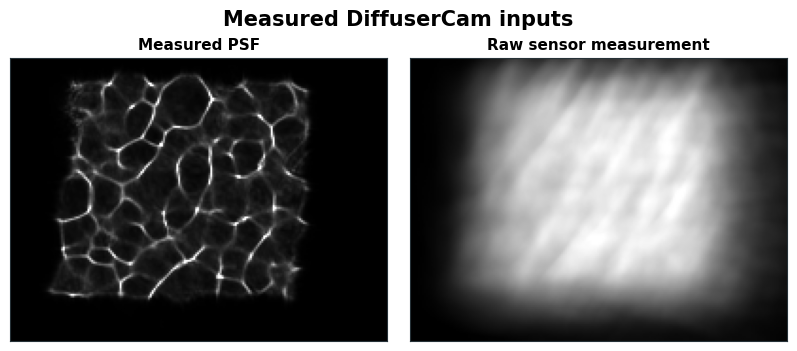

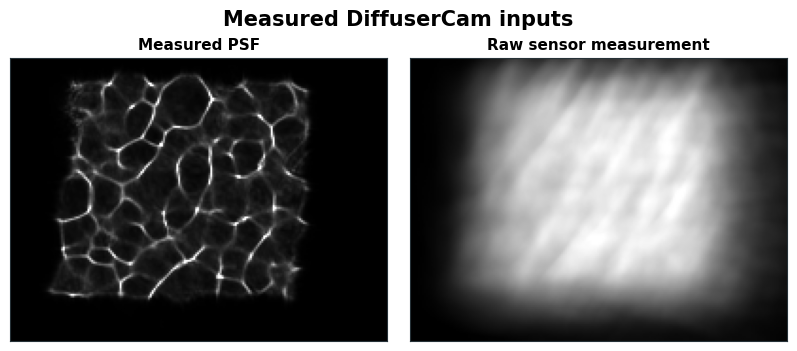

In [20]:
plot_image_grid(
    [
        ('Measured PSF', sample.psf),
        ('Raw sensor measurement', sample.measurement),
    ],
    RESULT_DIR / '01_inputs.png',
    columns=2,
    title='Measured DiffuserCam inputs',
)

## Experiment Parameters

The Waller-style ADMM solver has three penalty parameters:

- `mu1`: agreement between full convolution variable `x` and `Mv`
- `mu2`: agreement between TV variable `u` and `Psi v`
- `mu3`: agreement between nonnegative variable `w` and `v`

The TV threshold is controlled by:

$$ \tau / \mu_2 $$

So, when tuning TV, `tau` and `mu2` should be interpreted together.

In [21]:
admm_base_parameters = {
    'mu1': 1e-6,
    'mu2': 1e-5,
    'mu3': 4e-5,
}

moderate_tau = 1e-9
snapshot_iterations = [0, 1, 2, 5, 10, 20, 40]
max_snapshot_iteration = max(snapshot_iterations)

{
    'moderate_tau': moderate_tau,
    'tau_over_mu2': moderate_tau / admm_base_parameters['mu2'],
    'snapshot_iterations': snapshot_iterations,
}

{'moderate_tau': 1e-09,
 'tau_over_mu2': 0.0001,
 'snapshot_iterations': [0, 1, 2, 5, 10, 20, 40]}

## 1. ADMM Iteration Snapshots

Your observation was that most image structure appears by about 5 iterations. This section makes that visible and reproducible.

The early iterations recover coarse object support and major edges. Later iterations refine contrast, suppress artifacts, and improve consistency with the measurement.

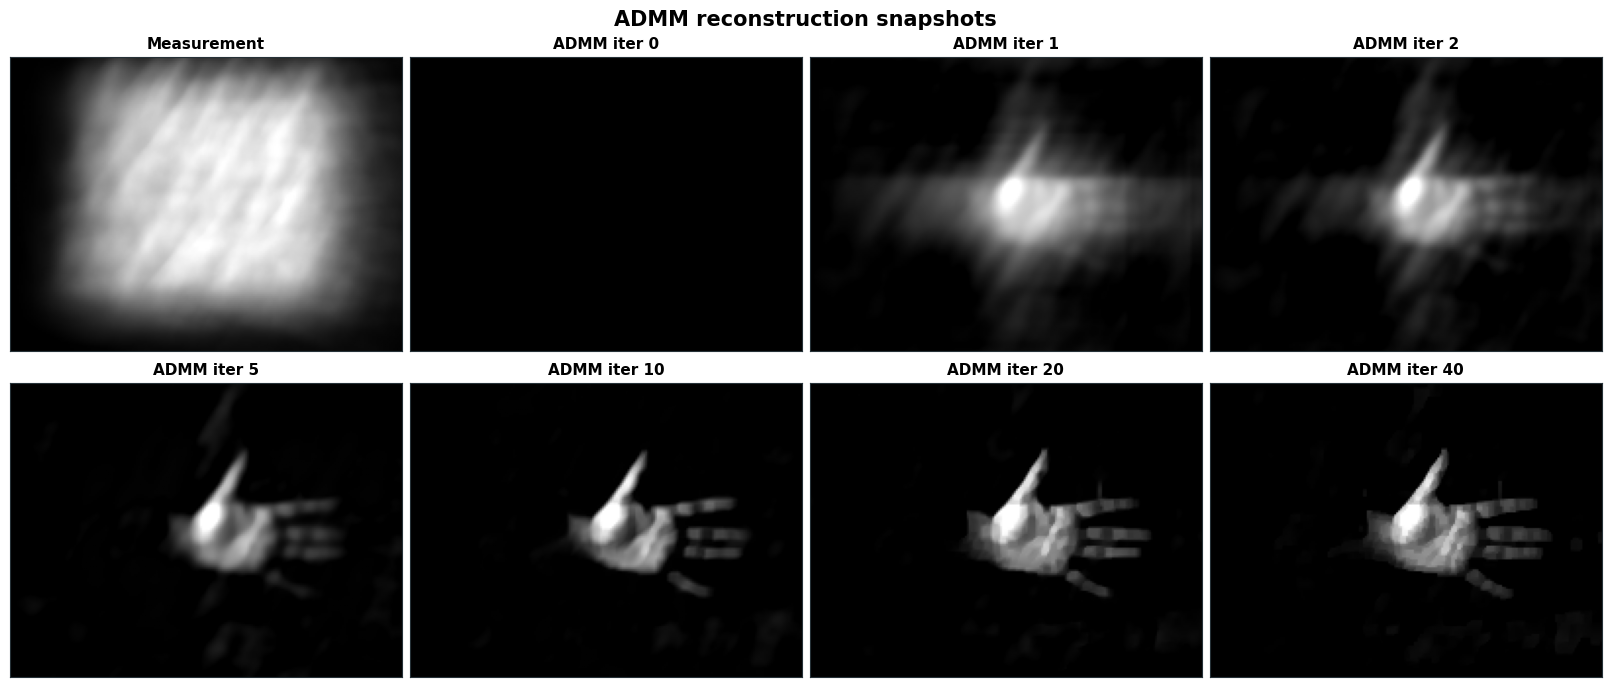

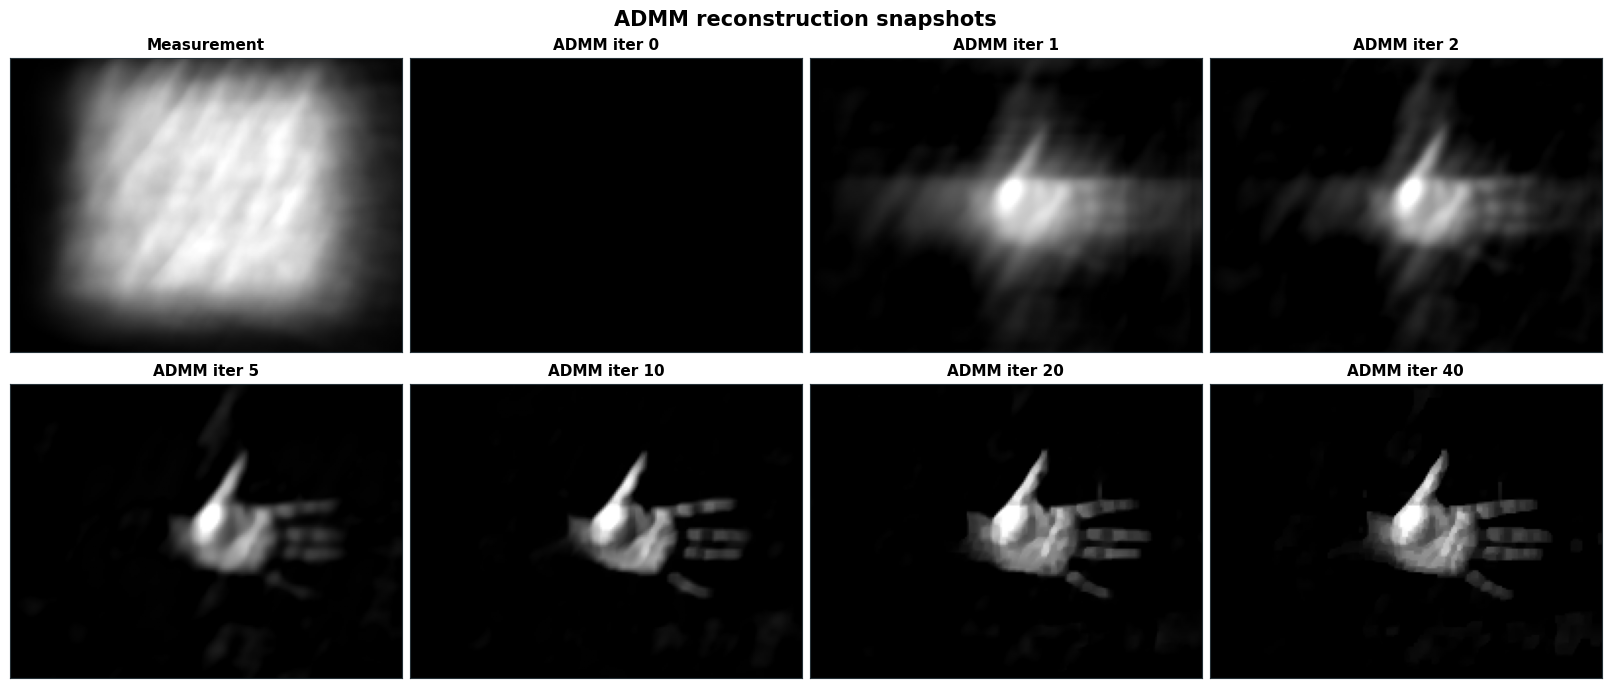

In [22]:
main_admm = admm_total_variation(
    operator=operator,
    measurement=sample.measurement,
    iterations=max_snapshot_iteration,
    record_every=1,
    tau=moderate_tau,
    snapshot_iterations=set(snapshot_iterations),
    **admm_base_parameters,
)

snapshot_tiles = [('Measurement', sample.measurement)]
snapshot_tiles += [(f'ADMM iter {iteration}', main_admm.snapshots[iteration]) for iteration in snapshot_iterations]

plot_image_grid(
    snapshot_tiles,
    RESULT_DIR / '02_admm_iteration_snapshots.png',
    columns=4,
    title='ADMM reconstruction snapshots',
)

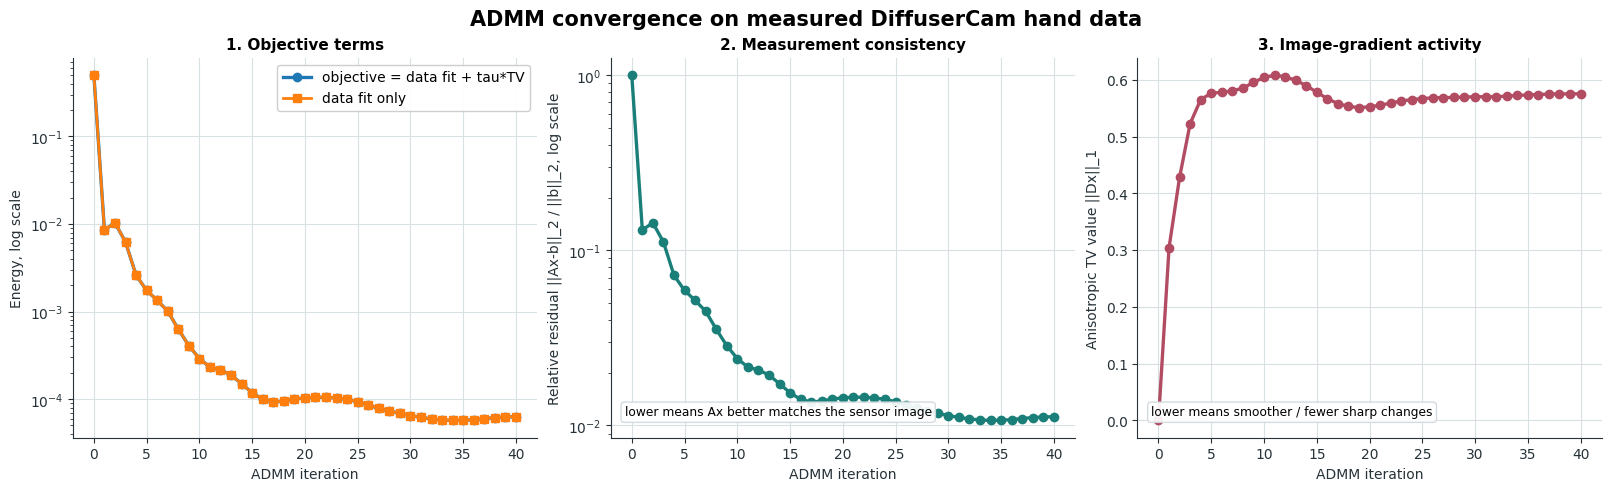

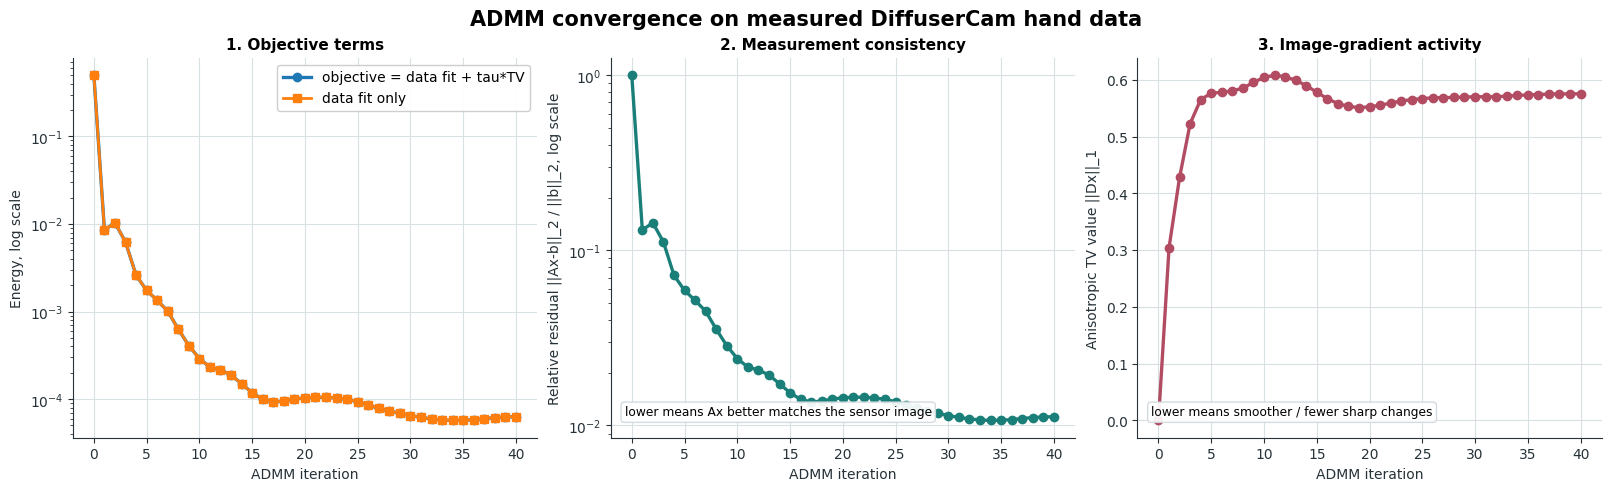

In [23]:
plot_admm_convergence(
    main_admm.history,
    RESULT_DIR / '03_admm_moderate_convergence.png',
)

### Observation

The hand becomes recognizable very early. This is common in inverse problems: the first iterations recover large-scale structure because those components dominate the residual. Fine details and artifacts require more iterations and better regularization tuning.

## 2. TV Strength Sweep

Now we sweep `tau` while holding `mu1`, `mu2`, and `mu3` fixed. The sweep uses 10 ADMM iterations because the goal is to understand early reconstruction behavior.

We measure:

- relative residual: how well the reconstruction explains the measurement
- TV value: how much image-gradient activity remains

A useful TV setting should reduce artifacts without erasing hand structure.

In [24]:
tau_values = [1e-10, 3e-10, 1e-9, 3e-9, 1e-8, 3e-8]
sweep_iterations = 10
tau_sweep_results = []
tau_sweep_tiles = [('Measurement', sample.measurement), ('PSF', sample.psf)]

for tau in tau_values:
    result = admm_total_variation(
        operator=operator,
        measurement=sample.measurement,
        iterations=sweep_iterations,
        record_every=sweep_iterations,
        tau=tau,
        **admm_base_parameters,
    )
    record = result.history[-1]
    tau_sweep_results.append(
        {
            'tau': tau,
            'tau_over_mu2': tau / admm_base_parameters['mu2'],
            'relative_residual_l2': record.relative_residual_l2,
            'tv_value': record.tv_value,
            'max_value': float(result.reconstruction.max()),
        }
    )
    tau_sweep_tiles.append((f'tau {tau:.0e}', result.reconstruction))

tau_sweep_results

[{'tau': 1e-10,
  'tau_over_mu2': 9.999999999999999e-06,
  'relative_residual_l2': 0.024453919968416234,
  'tv_value': 0.6588095548718709,
  'max_value': 0.002761311070638147},
 {'tau': 3e-10,
  'tau_over_mu2': 2.9999999999999997e-05,
  'relative_residual_l2': 0.024230909066716606,
  'tv_value': 0.6345095885691152,
  'max_value': 0.002723748637770123},
 {'tau': 1e-09,
  'tau_over_mu2': 0.0001,
  'relative_residual_l2': 0.02410209336197018,
  'tv_value': 0.6046554336945889,
  'max_value': 0.0026712969077283865},
 {'tau': 3e-09,
  'tau_over_mu2': 0.0003,
  'relative_residual_l2': 0.0229040811806656,
  'tv_value': 0.5543695025862725,
  'max_value': 0.0025355658189524246},
 {'tau': 1e-08,
  'tau_over_mu2': 0.001,
  'relative_residual_l2': 0.019151364347068687,
  'tv_value': 0.5136003871616864,
  'max_value': 0.002337362312108531},
 {'tau': 3e-08,
  'tau_over_mu2': 0.0029999999999999996,
  'relative_residual_l2': 0.019659912878491035,
  'tv_value': 0.511146833501256,
  'max_value': 0.002261

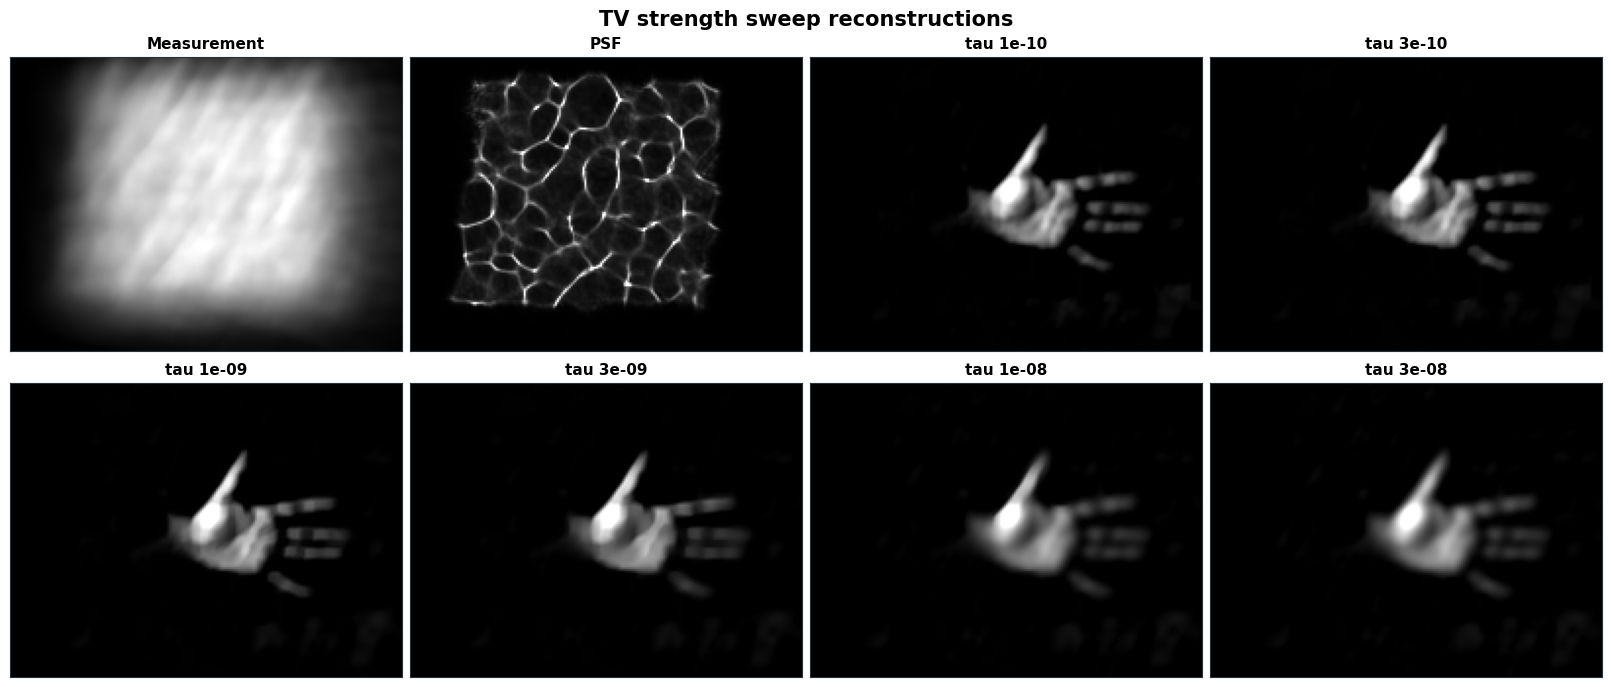

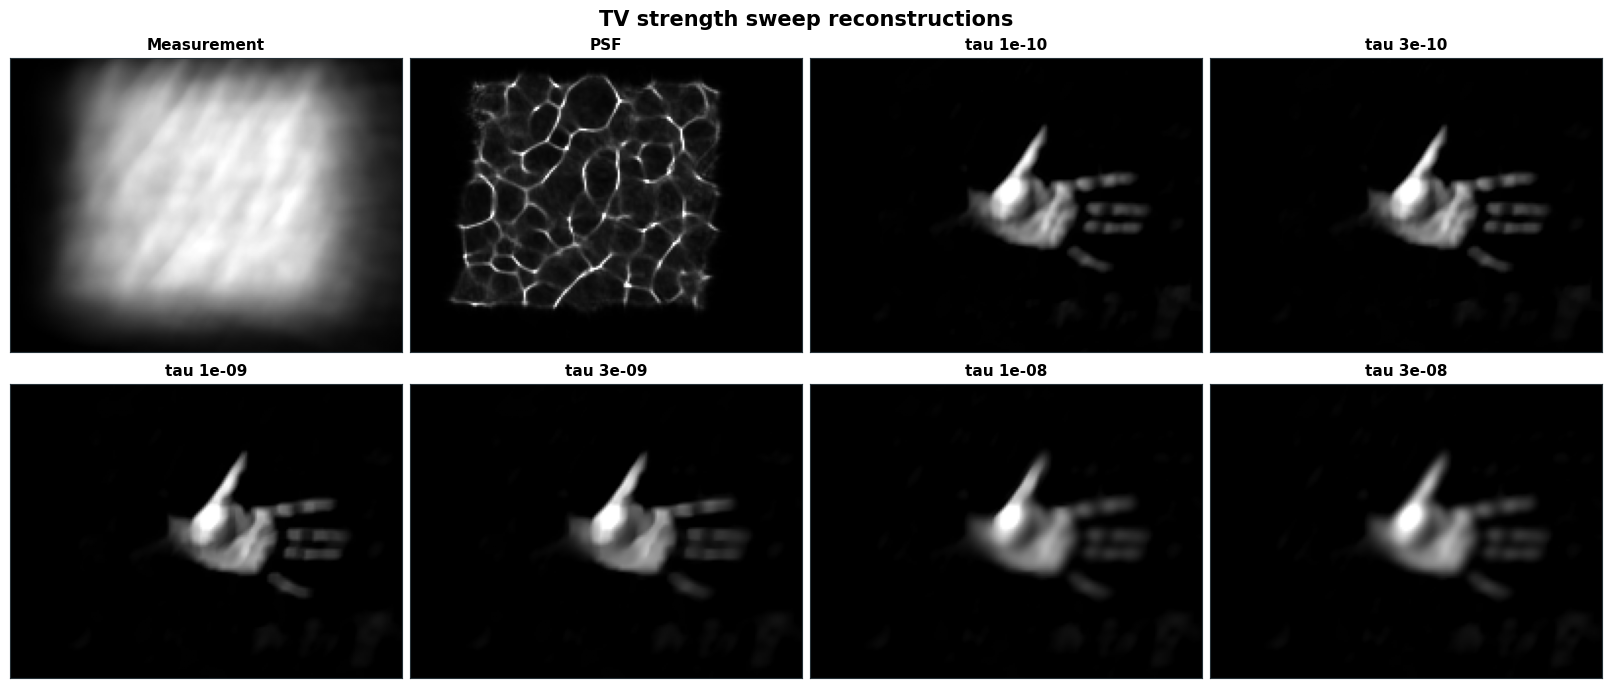

In [25]:
plot_image_grid(
    tau_sweep_tiles,
    RESULT_DIR / '04_tau_sweep_reconstructions.png',
    columns=4,
    title='TV strength sweep reconstructions',
)

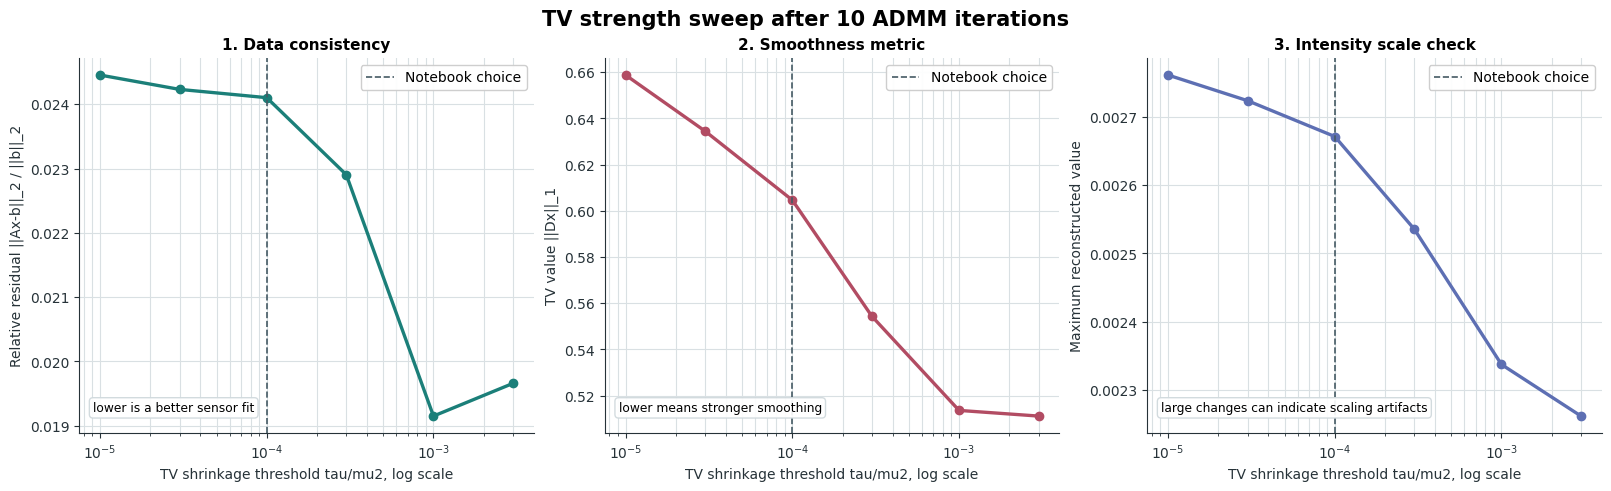

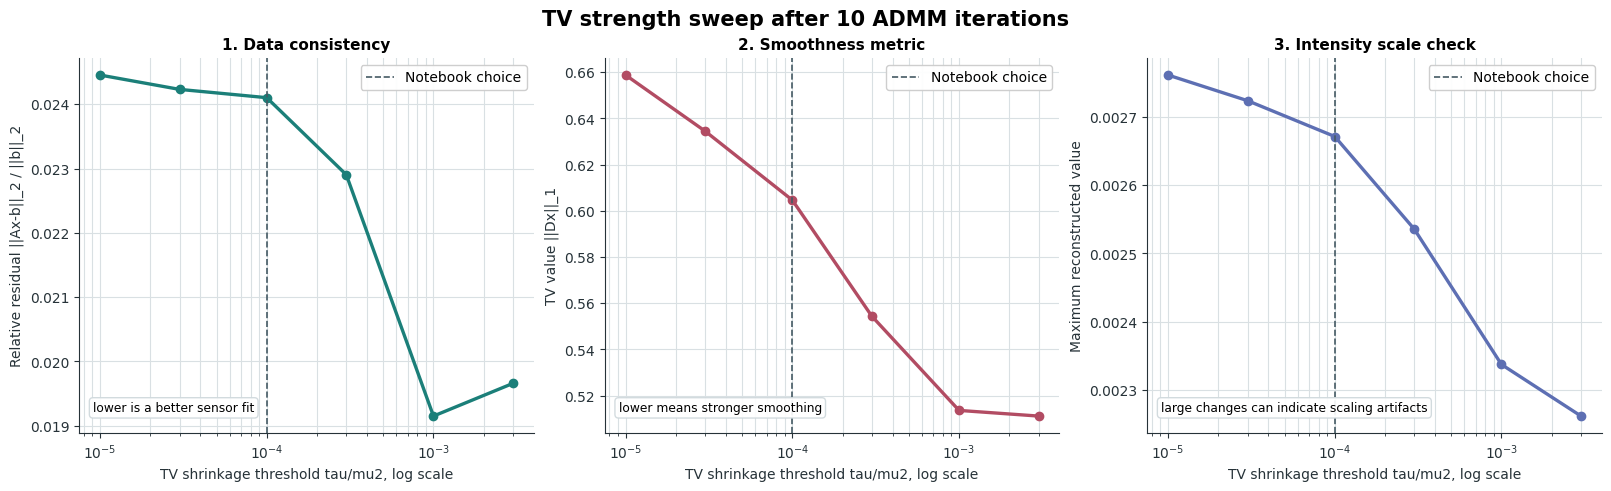

In [26]:
plot_tau_sweep(
    tau_sweep_results,
    RESULT_DIR / '05_tau_sweep_metrics.png',
)

### Observation

Increasing `tau` generally lowers the TV value, meaning the reconstruction has fewer/smaller finite differences. But high `tau` can make the hand blocky or suppress fingers. This is the central TV tradeoff: smoother images are not automatically better images.

## 3. Predicted Measurement and Residual

For measured data, we cannot compute PSNR. But we can compare the true sensor measurement `b` with the predicted measurement `A x_hat`.

This figure checks whether the reconstruction explains the sensor data or merely looks plausible.

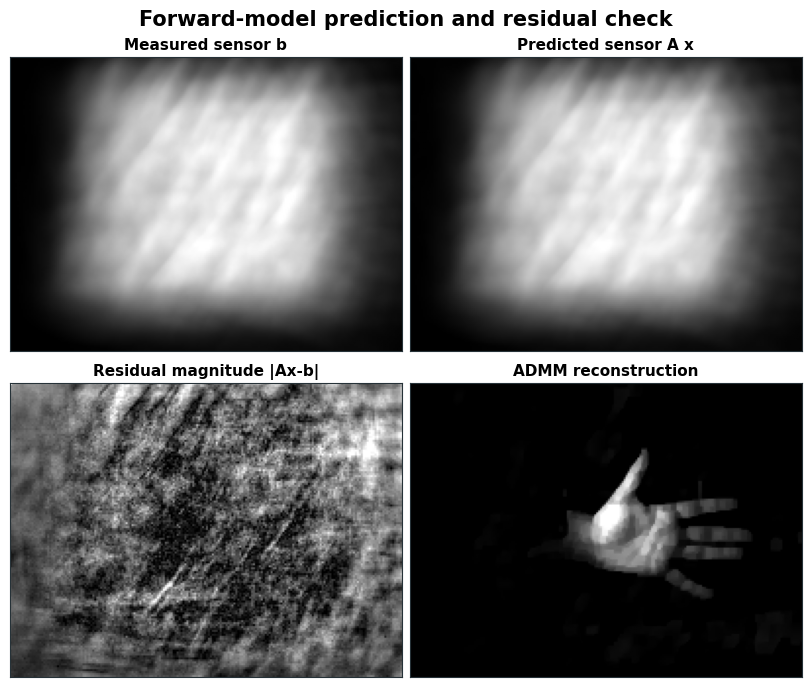

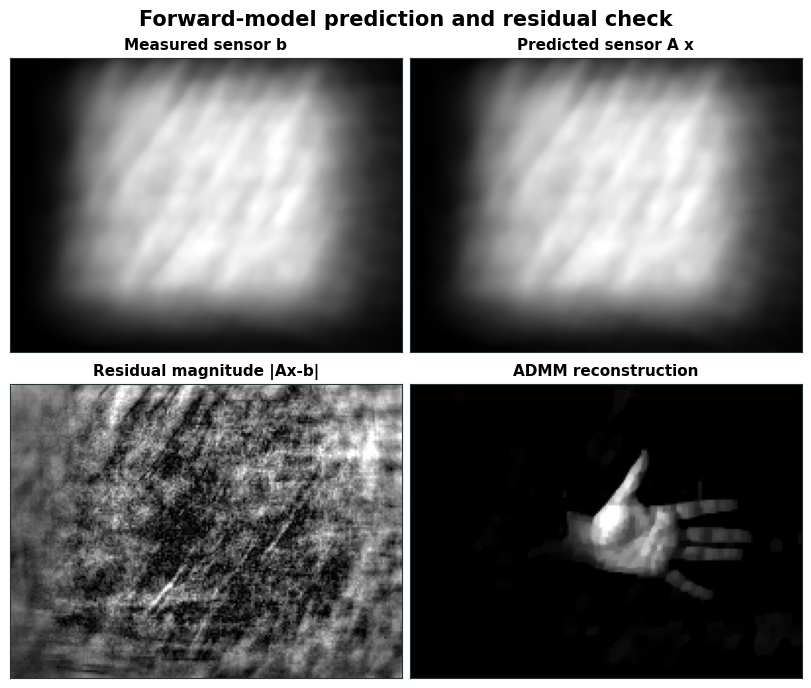

In [27]:
chosen_reconstruction = main_admm.reconstruction
chosen_prediction = operator.forward_padded(main_admm.padded_estimate)
chosen_residual = chosen_prediction - sample.measurement

plot_image_grid(
    [
        ('Measured sensor b', sample.measurement),
        ('Predicted sensor A x', chosen_prediction),
        ('Residual magnitude |Ax-b|', np.abs(chosen_residual)),
        ('ADMM reconstruction', chosen_reconstruction),
    ],
    RESULT_DIR / '06_prediction_residual_check.png',
    columns=2,
    title='Forward-model prediction and residual check',
)

### Observation

The residual is structured, not pure random noise. That tells us the remaining error is not only sensor noise; it likely includes model mismatch, downsampling effects, calibration mismatch, saturation/nonlinearities, and the limits of the shift-invariant convolution approximation.

## 4. Runtime vs Quality: FISTA and ADMM

ADMM often recovers structure in very few iterations, but an ADMM iteration is heavier than a FISTA iteration. A fair comparison should include runtime.

Here we run several iteration budgets and report elapsed time, residual, and TV value.

In [28]:
def evaluate_fista(iterations: int) -> dict[str, object]:
    start = perf_counter()
    result = fista(
        operator=operator,
        measurement=sample.measurement,
        iterations=iterations,
        record_every=iterations,
    )
    elapsed = perf_counter() - start
    prediction = operator.forward_padded(result.padded_estimate)
    return {
        'method': 'FISTA',
        'iterations': iterations,
        'seconds': elapsed,
        'relative_residual_l2': residual_relative_l2(sample.measurement, prediction),
        'tv_value': total_variation_anisotropic(result.padded_estimate),
        'max_value': float(result.reconstruction.max()),
    }

def evaluate_admm(iterations: int, tau: float) -> dict[str, object]:
    start = perf_counter()
    result = admm_total_variation(
        operator=operator,
        measurement=sample.measurement,
        iterations=iterations,
        record_every=iterations,
        tau=tau,
        **admm_base_parameters,
    )
    elapsed = perf_counter() - start
    record = result.history[-1]
    return {
        'method': 'ADMM-TV',
        'iterations': iterations,
        'seconds': elapsed,
        'relative_residual_l2': record.relative_residual_l2,
        'tv_value': record.tv_value,
        'max_value': float(result.reconstruction.max()),
    }

runtime_rows = []
for iterations in [10, 50, 100, 250]:
    runtime_rows.append(evaluate_fista(iterations))
for iterations in [2, 5, 10, 20, 40]:
    runtime_rows.append(evaluate_admm(iterations, moderate_tau))

runtime_rows

[{'method': 'FISTA',
  'iterations': 10,
  'seconds': 0.32435979999718256,
  'relative_residual_l2': 0.7317067200557549,
  'tv_value': 1.2594795718265246,
  'max_value': 0.002683419023225738},
 {'method': 'FISTA',
  'iterations': 50,
  'seconds': 1.4026715999934822,
  'relative_residual_l2': 0.027825971866678765,
  'tv_value': 0.3821555686600996,
  'max_value': 0.0015755989059437006},
 {'method': 'FISTA',
  'iterations': 100,
  'seconds': 2.7374093999969773,
  'relative_residual_l2': 0.008894485168719598,
  'tv_value': 0.5215694660883827,
  'max_value': 0.0022552164656884843},
 {'method': 'FISTA',
  'iterations': 250,
  'seconds': 6.726762300007977,
  'relative_residual_l2': 0.005005277747519048,
  'tv_value': 0.6175120495420463,
  'max_value': 0.00244115142636182},
 {'method': 'ADMM-TV',
  'iterations': 2,
  'seconds': 0.1881281999812927,
  'relative_residual_l2': 0.14360277147085565,
  'tv_value': 0.42856085076471134,
  'max_value': 0.0011823546917241693},
 {'method': 'ADMM-TV',
  'i

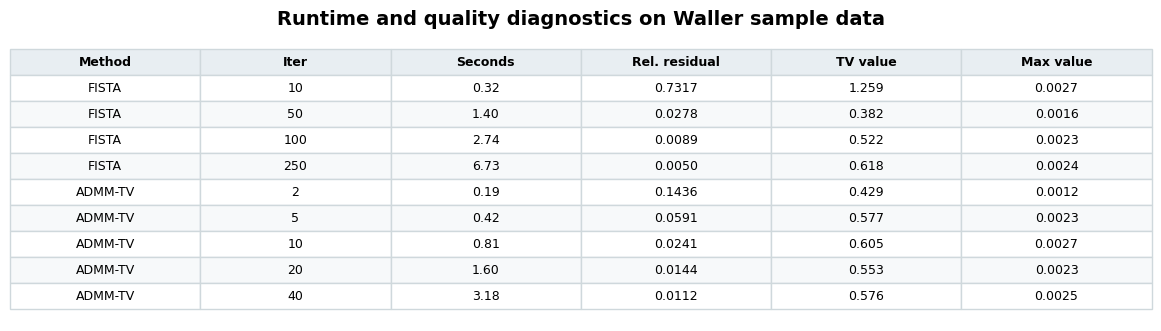

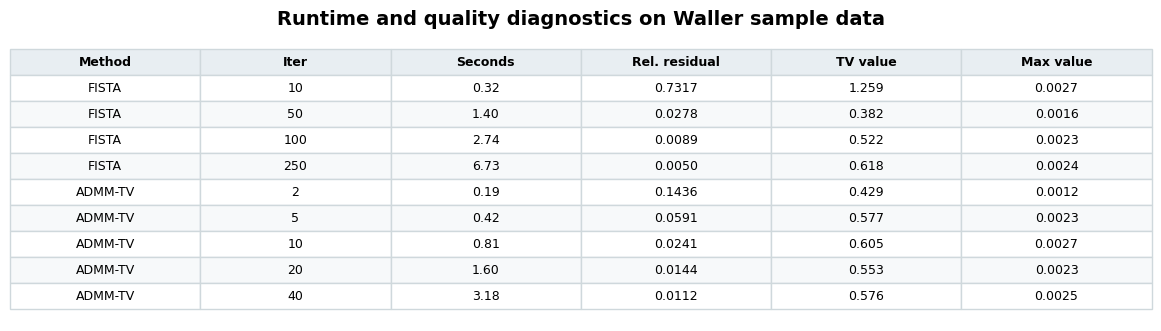

In [29]:
plot_runtime_table(
    runtime_rows,
    RESULT_DIR / '07_runtime_quality_table.png',
)

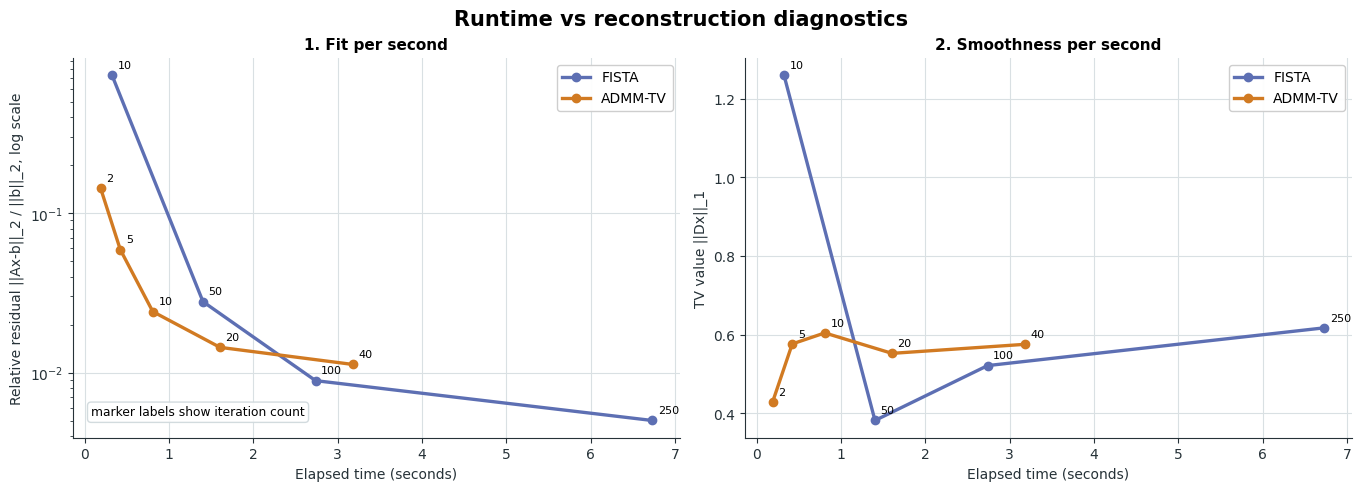

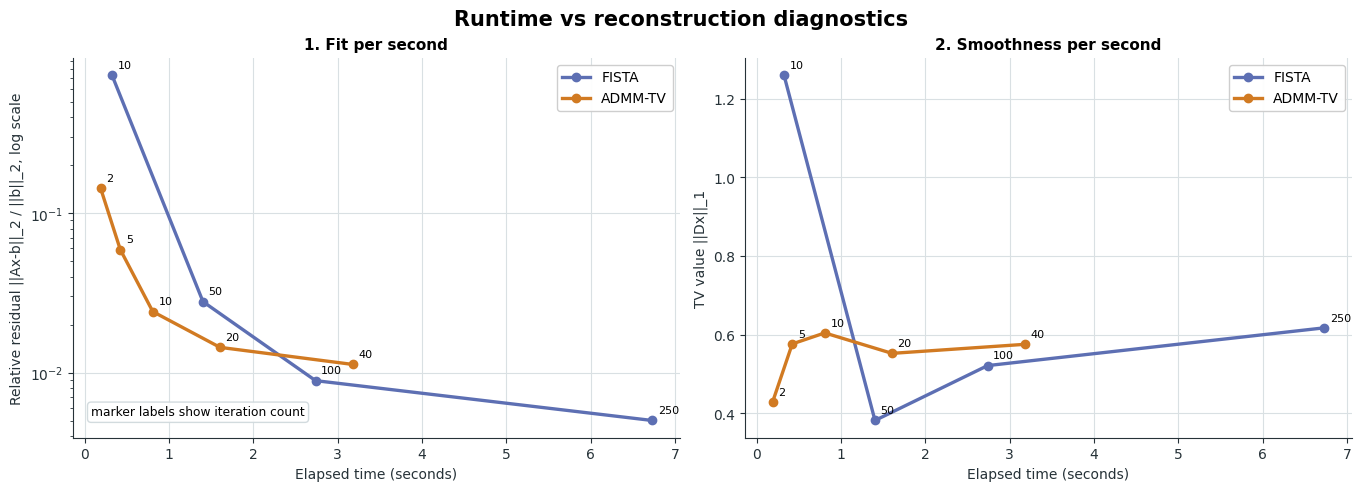

In [30]:
plot_runtime_quality(
    runtime_rows,
    RESULT_DIR / '08_runtime_quality_plot.png',
)

### Observation

ADMM gives recognizable structure in very few iterations, but FISTA can reach a lower residual after many inexpensive iterations. This means the best solver depends on the goal:

- fast preview reconstruction: ADMM with a small iteration budget is attractive,
- lowest residual under this model: longer FISTA can be competitive,
- visually cleaner reconstruction: TV-ADMM gives more direct control over image-gradient artifacts.

## Summary for Portfolio

This notebook demonstrates a complete diagnostic workflow for measured lensless imaging data:

- calibrated PSF and raw measurement loading,
- ADMM iteration snapshots,
- TV strength sweep,
- predicted-measurement residual analysis,
- runtime-vs-quality comparison with FISTA.

The most important finding is that coarse image structure appears early, but later iterations and TV tuning determine artifact level and detail preservation. This is exactly why reconstruction algorithms should be evaluated with both quantitative diagnostics and visual checks.

In [31]:
summary = {
    'data_info': data_info,
    'admm_base_parameters': admm_base_parameters,
    'moderate_tau': moderate_tau,
    'snapshot_iterations': snapshot_iterations,
    'main_admm_final': main_admm.history[-1].__dict__,
    'tau_sweep': tau_sweep_results,
    'runtime_rows': runtime_rows,
}

(RESULT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
print(json.dumps(summary, indent=2))

{
  "data_info": {
    "psf_path": "E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\psf_sample.tif",
    "rawdata_path": "E:\\RIT\\Spring2026\\ComputationalImaging\\DiffuserCam2026\\data\\external\\tutorial\\rawdata_hand_sample.tif",
    "raw_shape_rows_cols": [
      1200,
      1600
    ],
    "processed_shape_rows_cols": [
      150,
      200
    ],
    "padded_shape": [
      512,
      512
    ],
    "background": 34.08,
    "imaging_adjoint_error": 2.056579521084895e-15
  },
  "admm_base_parameters": {
    "mu1": 1e-06,
    "mu2": 1e-05,
    "mu3": 4e-05
  },
  "moderate_tau": 1e-09,
  "snapshot_iterations": [
    0,
    1,
    2,
    5,
    10,
    20,
    40
  ],
  "main_admm_final": {
    "iteration": 40,
    "objective": 6.308179165822227e-05,
    "data_fit": 6.308121596086001e-05,
    "tv_value": 0.5756973622640962,
    "relative_residual_l2": 0.011232205122847429,
    "nonnegativity_violation_l2": 0.0
  },
  "tau_sweep": [
    {
      